In [18]:
import numpy as np
import scipy
from Pauli_path_Heis import *
import time

def change_noise_scale(s,damp_out):
    return np.exp(s*np.log(damp_out))

In [23]:
phi = np.pi/20

trans_codes, probs, is_commuting, branch_sign, amp_factr = build_transition_tables(phi)

n_qubits = 12

#Build Trotter step gate pairs
GTL = []
for j in range(0, n_qubits, 2):
    GTL.append([j, j+1])
for j in range(1, n_qubits-1, 2):
    GTL.append([j, j+1])



P0 = np.array([3,0,3] + [0]*(n_qubits-3) , dtype=np.int8) # ZIZI^(N-3)



eta=np.exp(-.005)
steps = [1,2,3,4,5,6]
s=[0,0.5,1,2,4,8]
n_samples = int(1e8)
means = np.zeros([len(s),len(steps)])
stds = np.zeros([len(s),len(steps)])
for j in range(len(steps)):
    n_steps=steps[j]
    gates = np.array(GTL*n_steps, dtype=np.int64)
    t0 = time.time()
    
    P_out, s_out, amp_out,damp_out = evolve_many_paths_with_1q_noise(
        P0,
        gates,
        trans_codes, probs, is_commuting, branch_sign,
        amp_factr,
        eta,
        n_samples
    )

    out_mean=np.zeros(len(s))
    out_std = np.zeros(len(s))
    for k in range(len(s)):
        contribs=bond_projector_contribs(P_out, s_out, amp_out, change_noise_scale(s[k],damp_out))
        means[k,j]=np.mean(contribs)
        stds[k,j] = np.std(contribs)/np.sqrt(n_samples)
        
    
    print(j,time.time()-t0)

0 16.275640726089478
1 22.847673654556274
2 25.738343954086304
3 31.254858016967773
4 35.704962968826294
5 40.741326093673706


In [22]:
np.std(contribs)

0.5438490151942332

In [18]:
# def change_noise_scale(s,damp_out):
#     return np.exp(s*np.log(damp_out))

# s=[0,0.5,1,2,4,8]
# out_mean=np.zeros(len(s))
# out_std = np.zeros(len(s))
# for j in range(len(s)):
#     contribs=bond_projector_contribs(P_out, s_out, amp_out, change_noise_scale(s[j],damp_out))
#     out_mean[j]=np.mean(contribs)
#     out_std[j] = np.std(contribs)/np.sqrt(n_samples)
#     print(s[j],out_mean[j],out_std[j])

0 0.3808205701105909 0.1496089303902122
0.5 0.35240322078595443 0.137143761387679
1 0.32623837289146884 0.12578299326236467
2 0.2799409995789797 0.1059759077406176
4 0.20719730898764194 0.07572328818539936
8 0.11604184640912378 0.03974136087866923


Text(0, 0.5, '$\\langle Z_0Z_2\\rangle $')

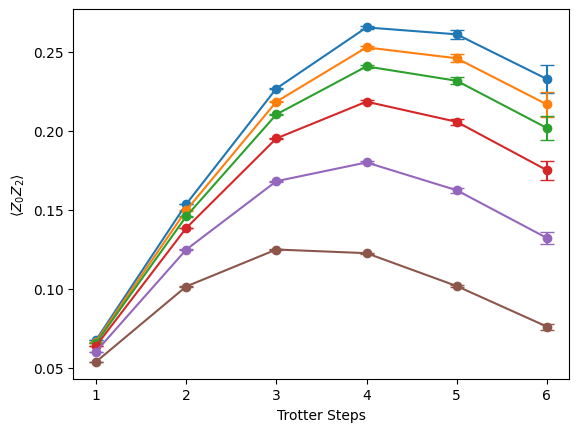

In [25]:
from matplotlib import pyplot as plt
for j in range(len(s)):
    plt.errorbar(steps, means[j,:], yerr=stds[j,:], fmt='-o', capsize=5)

# plt.yscale('log')
plt.xlabel('Trotter Steps')
plt.ylabel(r'$\langle Z_0Z_2\rangle $')

Text(0, 0.5, '$\\langle Z_0Z_2\\rangle $')

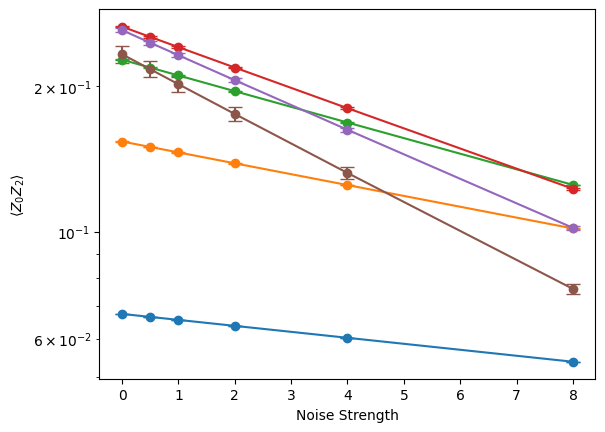

In [27]:
for j in range(len(steps)):
    plt.errorbar(s, means[:,j], yerr=stds[:,j], fmt='-o', capsize=5)

plt.yscale('log')
plt.xlabel('Noise Strength')
plt.ylabel(r'$\langle Z_0Z_2\rangle $')